In [2]:
import os
import cv2

output_folder = "Prepared datasets"
os.makedirs(output_folder, exist_ok=True)

image_files = sorted([
    f for f in os.listdir()
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(image_files)

['grid.png', 'horizontal_lines.png', 'image1.jpeg', 'image2.jpeg', 'image3.jpeg', 'vertical_lines.png']


In [3]:
for image_name in image_files:

    print("Processing:", image_name)

    IMAGE_PATH = image_name

    img = cv2.imread(IMAGE_PATH)

    # Run Part 1
    # Run Part 2
    # Run Part 3
    # Run Part 4

print("Done!")

Processing: grid.png
Processing: horizontal_lines.png
Processing: image1.jpeg
Processing: image2.jpeg
Processing: image3.jpeg
Processing: vertical_lines.png
Done!


In [4]:
import os
import cv2
import numpy as np

count = 0

for image_name in image_files:

    print("Processing:", image_name)

    # =====================================
    # PART 1
    # =====================================
    img = cv2.imread(image_name)
    img = cv2.imread(image_name)

    if img is None:
        print(f"❌ Cannot read image: {image_name}")
        continue

    TARGET_HEIGHT = 1500
    scale = TARGET_HEIGHT / img.shape[0]
    TARGET_WIDTH = int(img.shape[1] * scale)

    img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    binary = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        15
    )



Processing: grid.png


Processing: horizontal_lines.png
Processing: image1.jpeg
Processing: image2.jpeg
Processing: image3.jpeg
Processing: vertical_lines.png


Processing: image1.jpeg
Original Shape : (1518, 1074, 3)
Resized Shape : (1500, 1061, 3)


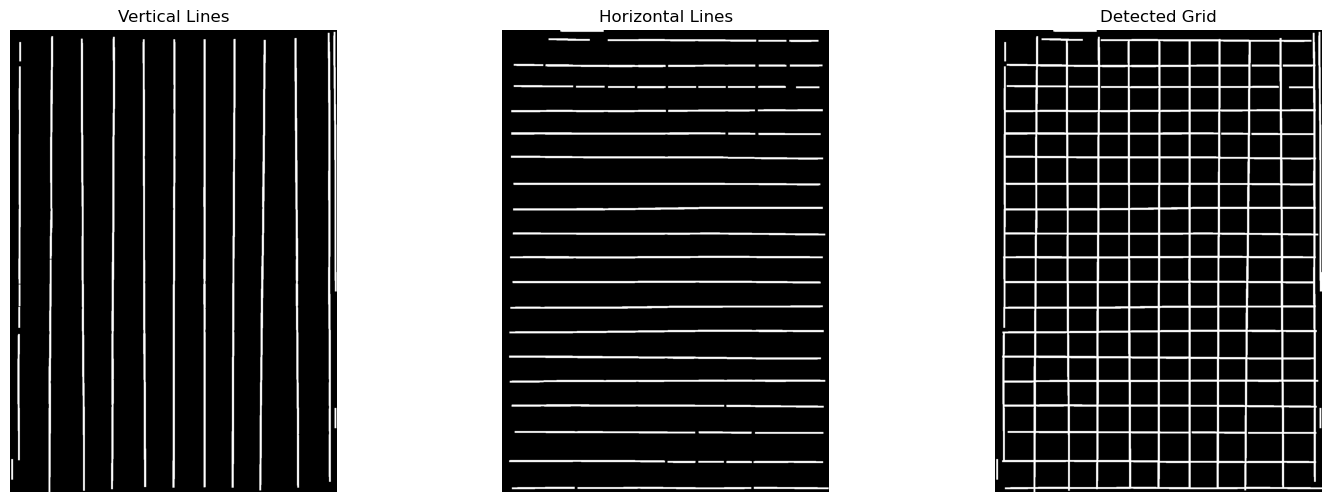

✅ image1.jpeg : Part 1 & Part 2 Completed
Vertical Grid Lines: 11
Horizontal Grid Lines: 19

Horizontal Grid Lines: 19
[33, 115, 184, 262, 336, 413, 499, 579, 661, 737, 818, 899, 977, 1063, 1139, 1219, 1306, 1400, 1486]


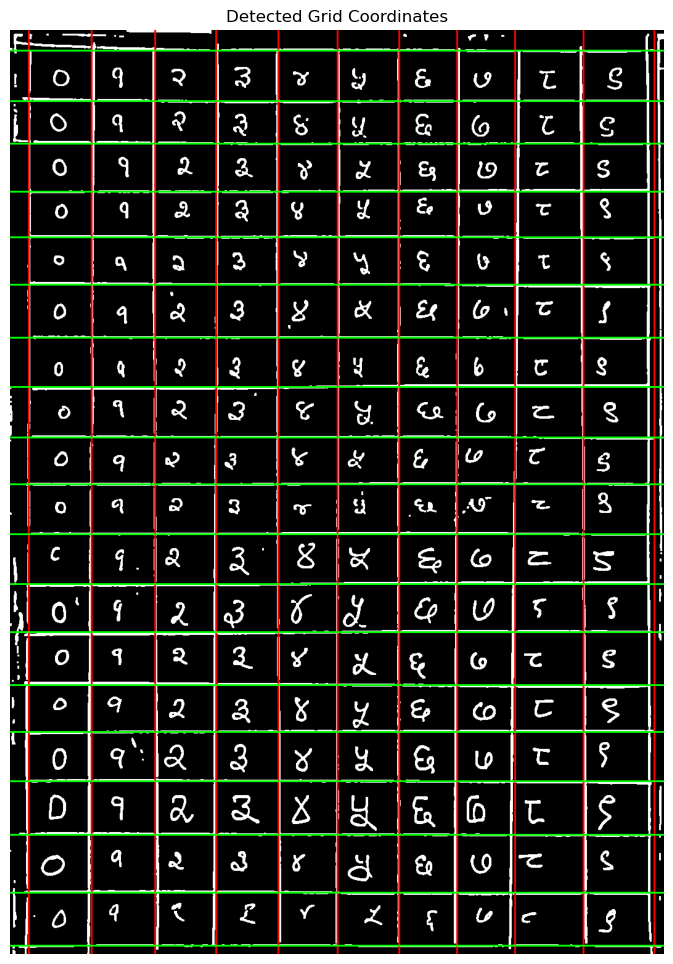

Processing: image2.jpeg
Original Shape : (1500, 1076, 3)
Resized Shape : (1500, 1076, 3)


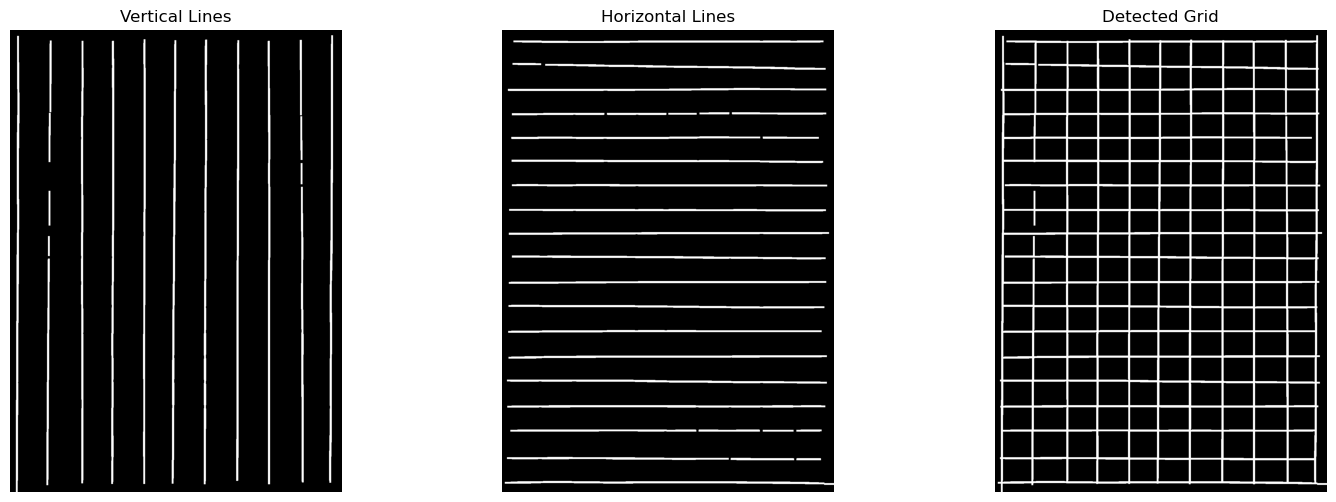

✅ image2.jpeg : Part 1 & Part 2 Completed
Vertical Grid Lines: 11
Horizontal Grid Lines: 19

Horizontal Grid Lines: 19
[37, 119, 193, 272, 349, 425, 504, 584, 659, 737, 818, 897, 977, 1060, 1140, 1221, 1300, 1391, 1468]


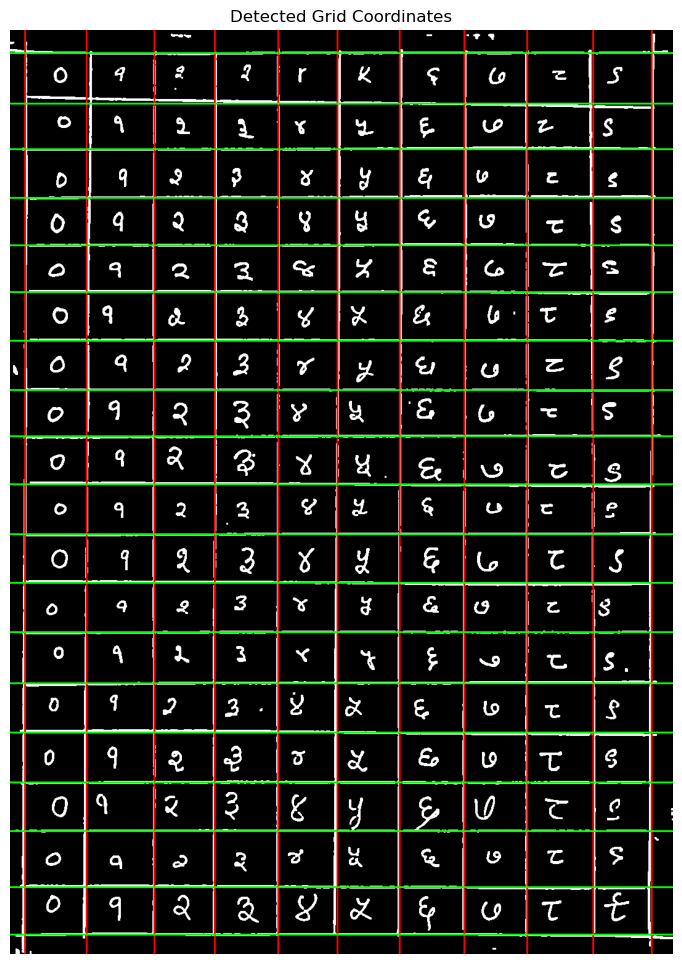

Processing: image3.jpeg
Original Shape : (1500, 1078, 3)
Resized Shape : (1500, 1078, 3)


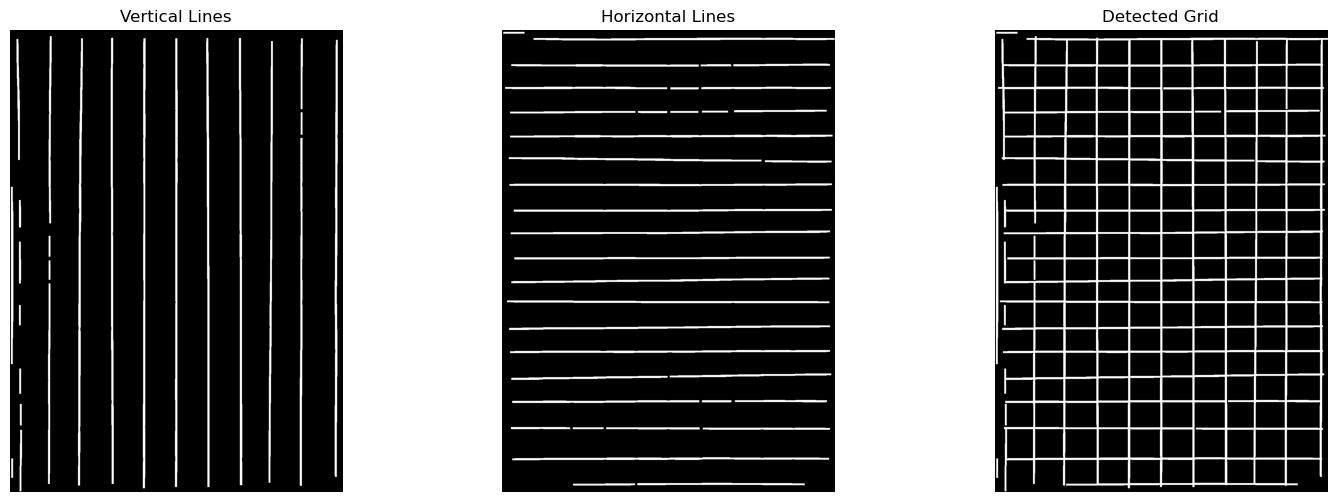

✅ image3.jpeg : Part 1 & Part 2 Completed
Vertical Grid Lines: 12
Horizontal Grid Lines: 19

Horizontal Grid Lines: 19
[29, 114, 188, 265, 344, 421, 502, 586, 658, 740, 812, 883, 965, 1044, 1125, 1205, 1293, 1391, 1473]


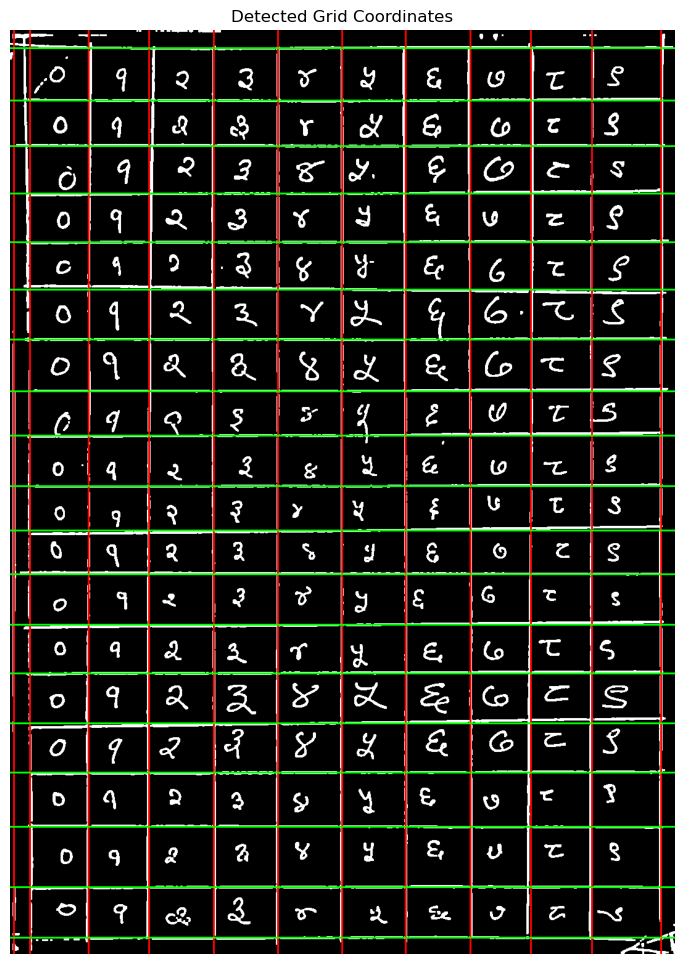

--------------------------------
Finished
Total Images Saved: 558


In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Images to Process
# ==========================================
image_files = [
    "image1.jpeg",
    "image2.jpeg",
    "image3.jpeg"
]

for image_name in image_files:

    print("=" * 60)
    print("Processing:", image_name)

    # ==========================================
    # Read Image
    # ==========================================
    img = cv2.imread(image_name)

    if img is None:
        print(f"❌ Cannot read {image_name}")
        continue

    # ==========================================
    # PART 1 : PREPROCESSING
    # ==========================================

    print("Original Shape :", img.shape)

    TARGET_HEIGHT = 1500

    scale = TARGET_HEIGHT / img.shape[0]

    TARGET_WIDTH = int(img.shape[1] * scale)

    img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT))

    print("Resized Shape :", img.shape)

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    binary = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        15
    )

    kernel = np.ones((3,3), np.uint8)

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    # ==========================================
    # PART 2 : GRID DETECTION
    # ==========================================

    # Detect Vertical Lines
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (3, 60)
    )

    vertical = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    vertical = cv2.dilate(
        vertical,
        np.ones((3,3), np.uint8),
        iterations=2
    )

    vertical = cv2.erode(
        vertical,
        np.ones((2,2), np.uint8),
        iterations=1
    )

    # Detect Horizontal Lines
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (60,3)
    )

    horizontal = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    horizontal = cv2.dilate(
        horizontal,
        np.ones((3,3), np.uint8),
        iterations=2
    )

    horizontal = cv2.erode(
        horizontal,
        np.ones((2,2), np.uint8),
        iterations=1
    )

    # Combine Grid
    grid = cv2.bitwise_or(vertical, horizontal)

    kernel = np.ones((3,3), np.uint8)

    grid = cv2.morphologyEx(
        grid,
        cv2.MORPH_CLOSE,
        kernel
    )

    # ==========================================
    # DISPLAY
    # ==========================================

    plt.figure(figsize=(18,6))

    plt.subplot(1,3,1)
    plt.imshow(vertical, cmap="gray")
    plt.title("Vertical Lines")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(horizontal, cmap="gray")
    plt.title("Horizontal Lines")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(grid, cmap="gray")
    plt.title("Detected Grid")
    plt.axis("off")

    plt.show()

    print(f"✅ {image_name} : Part 1 & Part 2 Completed")





    # -----------------------------
    # Find Vertical Line Coordinates
    # -----------------------------
    vertical_projection = np.sum(vertical // 255, axis=0)

    threshold = int(vertical.shape[0] * 0.4)

    x_positions = np.where(vertical_projection > threshold)[0]
        # -----------------------------
    # Find Horizontal Line Coordinates
    # -----------------------------
    horizontal_projection = np.sum(horizontal // 255, axis=1)

    horizontal_threshold = int(horizontal.shape[1] * 0.4)

    y_positions = np.where(horizontal_projection > horizontal_threshold)[0]

    # Merge nearby x positions
    def merge_lines(positions, gap=15):
        if len(positions) == 0:
            return []

        positions = sorted(positions)

        merged = []
        current_group = [positions[0]]

        for p in positions[1:]:
            if p - current_group[-1] <= gap:
                current_group.append(p)
            else:
                merged.append(int(sum(current_group) / len(current_group)))
                current_group = [p]

        merged.append(int(sum(current_group) / len(current_group)))

        return merged


    merged_x = merge_lines(x_positions, gap=15)
    merged_y = merge_lines(y_positions, gap=15)

    print("Vertical Grid Lines:", len(merged_x))
    print("Horizontal Grid Lines:", len(merged_y))

    print("\nHorizontal Grid Lines:", len(merged_y))
    print(merged_y)

    # -----------------------------
    # Draw Detected Grid
    # -----------------------------
    debug = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)

    for x in merged_x:
        cv2.line(debug, (x, 0), (x, debug.shape[0]), (255, 0, 0), 2)

    for y in merged_y:
        cv2.line(debug, (0, y), (debug.shape[1], y), (0, 255, 0), 2)

    plt.figure(figsize=(10,12))
    plt.imshow(debug)
    plt.title("Detected Grid Coordinates")
    plt.axis("off")
    plt.show()




    margin = 5

    for row in range(len(merged_y)-1):

        for col in range(len(merged_x)-1):

            x1 = merged_x[col] + margin
            x2 = merged_x[col+1] - margin

            y1 = merged_y[row] + margin
            y2 = merged_y[row+1] - margin

            if x2 <= x1 or y2 <= y1:
                continue

            cell = img[y1:y2, x1:x2]
            filename = os.path.join(
                output_folder,
                f"img_{count:05d}.png"
            )

            cv2.imwrite(filename, cell)

            count += 1

print("--------------------------------")
print("Finished")
print("Total Images Saved:", count)

In [6]:
label = sorted_sequence_index % 10

NameError: name 'sorted_sequence_index' is not defined